# Generation smoke test

Resolve and invoke a generator through `GENERATOR_REGISTRY`. This notebook checks the object API only; it does not test file output or PNG rendering.

In [ ]:
from pathlib import Path

import sys
import cv2
import numpy as np

from IPython.display import Image, SVG, display

# Works when launched from the repository root or this notebook directory.
project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / '01_scripts').exists():
    project_root = project_root.parent

scripts_root = project_root / '01_scripts'
if str(scripts_root) not in sys.path:
    sys.path.insert(0, str(scripts_root))

from generation.core.models import GeneratedObject, GenerationConfig
from generation.core.rendering import render_png
from generation.registry import GENERATOR_REGISTRY

In [ ]:
class_name = 'sc'
generator = GENERATOR_REGISTRY[class_name]

generated = generator(
  GenerationConfig(
    canvas_width_px=25,
    canvas_height_px=25,
    target_visible_px=15.0,
    rotation_deg=15.0,
  )
)

print(generated.class_name, generated.phenotype)

sc square_symmetric_cross


In [30]:
assert isinstance(generated, GeneratedObject)
assert generated.class_name == class_name
assert generated.svg
assert generated.metadata['class_name'] == class_name
assert generated.obb_pixels.shape == (4, 2)
assert generated.obb_normalized.shape == (4, 2)
assert generated.yolo_label.startswith('0 ')

print('GeneratedObject smoke test passed.')

GeneratedObject smoke test passed.


In [31]:
print('YOLO OBB label:')
print(generated.yolo_label)
display(SVG(data=generated.svg))

YOLO OBB label:
0 0.20000000 0.20000000 0.80000000 0.20000000 0.80000000 0.80000000 0.20000000 0.80000000


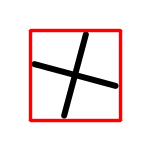

In [ ]:
inspection_dir = project_root / '02_notebooks' / 'generation' / 'smoke_tests' / 'outputs'
inspection_dir.mkdir(parents=True, exist_ok=True)

enlarged_px = 150
png_path = inspection_dir / f'{generated.class_id}_{generated.class_name}_smoke_{enlarged_px}px.png'
overlay_path = inspection_dir / f'{generated.class_id}_{generated.class_name}_smoke_{enlarged_px}px_overlay.png'

render_png(
  generated.svg,
  png_path,
  output_width=enlarged_px,
  output_height=enlarged_px,
  background_color='white',
)

rgba = cv2.imread(str(png_path), cv2.IMREAD_UNCHANGED)
if rgba is None:
  raise RuntimeError(f'Could not read rendered PNG: {png_path}')

# CairoSVG preserves transparency. Composite it onto white because
# cv2.imread() otherwise treats transparent pixels as black.
if rgba.ndim == 3 and rgba.shape[2] == 4:
  alpha = rgba[:, :, 3:4].astype(np.float32) / 255.0
  foreground = rgba[:, :, :3].astype(np.float32)
  image = (foreground * alpha + 255.0 * (1.0 - alpha)).astype(np.uint8)
else:
  image = rgba

scale = np.array([
  enlarged_px / generated.canvas_size_px[0],
  enlarged_px / generated.canvas_size_px[1],
])
obb = np.round(generated.obb_pixels * scale).astype(np.int32)
cv2.polylines(image, [obb.reshape((-1, 1, 2))], True, (0, 0, 255), 2, cv2.LINE_AA)

if not cv2.imwrite(str(overlay_path), image):
  raise RuntimeError(f'Could not write overlay: {overlay_path}')

display(Image(filename=str(overlay_path)))